In [1]:
import numpy as np
import matplotlib.pyplot as plt
from gps.gps_receiver import GpsReceiver

In [7]:
# fs = 4.092e6
fs = 4e6

# samples = np.fromfile("data/gpssim.ci16", dtype=np.int8, count=int(fs*2*10))
# samples = np.fromfile("data/gpssim.ci16", dtype=np.int8)
samples = np.fromfile("data/GPS-L1-2022-03-27.sigmf-data", dtype=np.int16)
samples = samples[::2].astype(np.complex64) + 1j * samples[1::2].astype(np.complex64)
print(samples.dtype, len(samples))

complex64 60000000


In [8]:
rx = GpsReceiver(fs, channels=12, debug=True)

i = 0

while i < len(samples):
    d = np.random.randint(256, 65536)
    # d = 16000

    new_samples = samples[i:i+d]
    rx.process(new_samples)

    i += d

[Acquisition] Searching 2.05ms period, N=8192
[Acquisition] 488.3Hz frequency bins
[Acquisition] SV: 11, Doppler shift: 2441.41Hz, Code sample phase: 725/4000, SNR: 8.6
[Acquisition] SV: 12, Doppler shift: -488.28Hz, Code sample phase: 590/4000, SNR: 7.6
[Acquisition] SV: 25, Doppler shift: 1464.84Hz, Code sample phase: 1660/4000, SNR: 7.2
[Acquisition] SV: 31, Doppler shift: 4882.81Hz, Code sample phase: 2186/4000, SNR: 7.6
[Acquisition] Fine freq: 2503.1 Hz, +-61.0 Hz
[Tracking] Starting tracking on SV 11
[Acquisition] Fine freq: -183.2 Hz, +-61.0 Hz
[Tracking] Starting tracking on SV 12
[Acquisition] Fine freq: 1770.5 Hz, +-61.0 Hz
[Tracking] Starting tracking on SV 25
[Acquisition] Fine freq: 5067.2 Hz, +-61.0 Hz
[Tracking] Starting tracking on SV 31
[Decoder SV: 12] Subframe 2, ToW 124146, sample 7439409, iode=74, c_rs=495.6, delta_n=-1.661e-09, M0=0.844, c_uc=-4.528e-05, e=0.4995, c_us=-4.849e-05, sqrtA=1936.7, t_oe=192512
[Decoder SV: 25] Subframe 2, ToW 124146, sample 7410331, 

In [ ]:
for i in range(np.sum(rx.acquired > 0)):
    iq = rx.channels[i].decoder.sample_buffer
    iq = np.array(iq, dtype=np.complex64)

    iq.tofile(f"data/downsampled{i}.cf64")

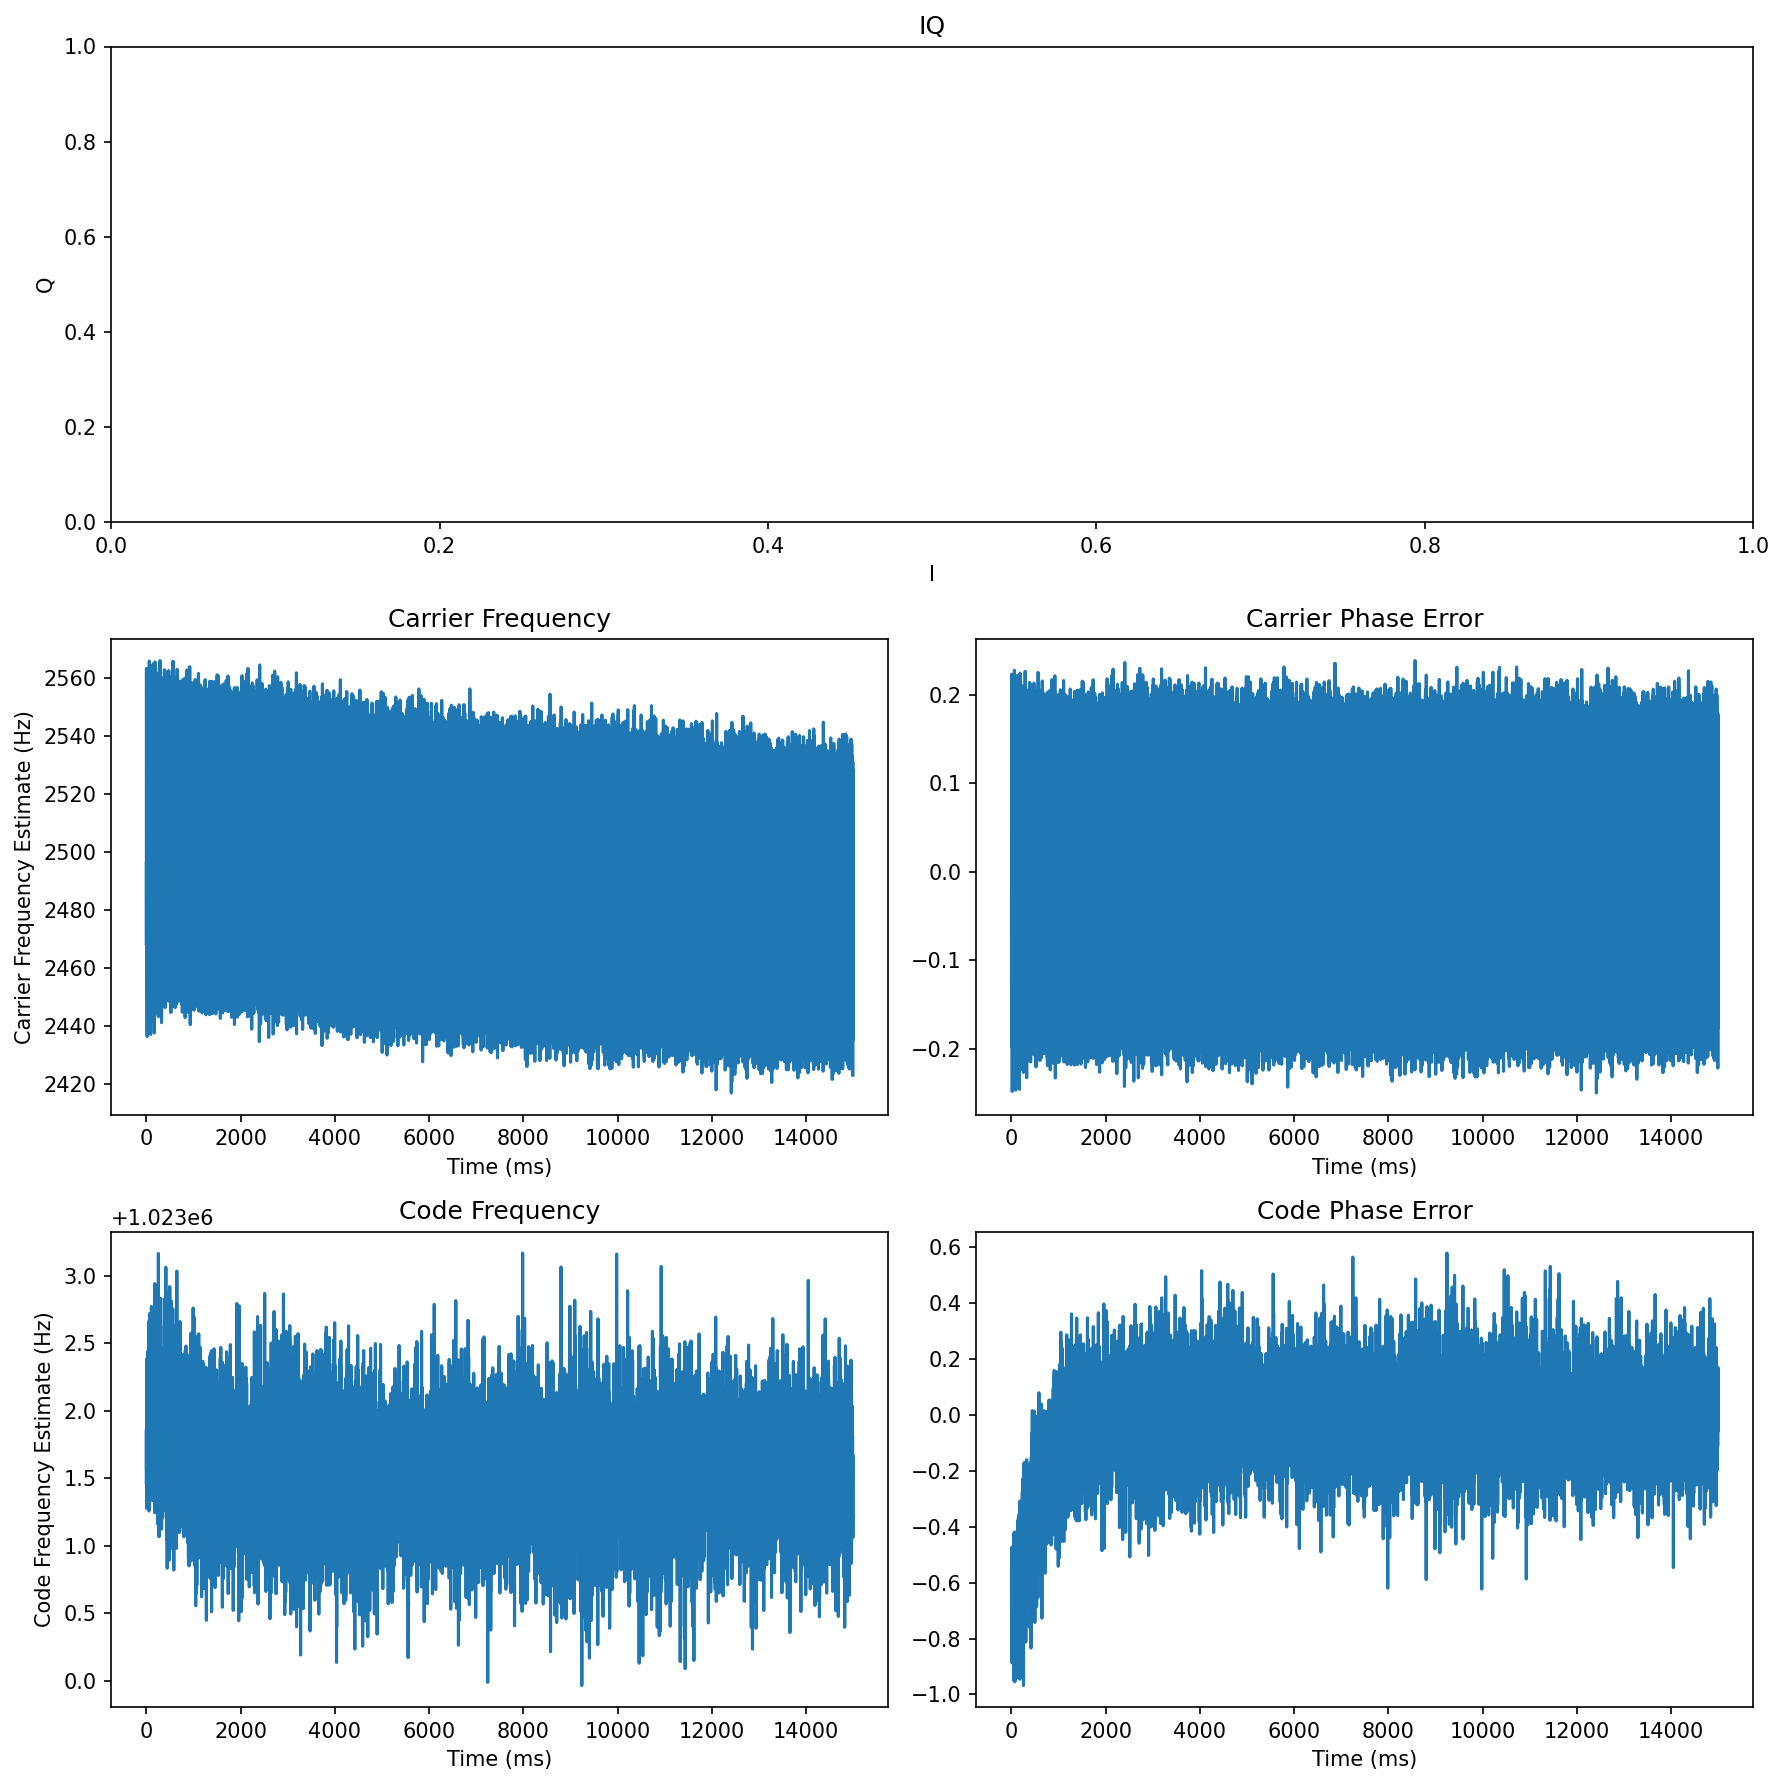

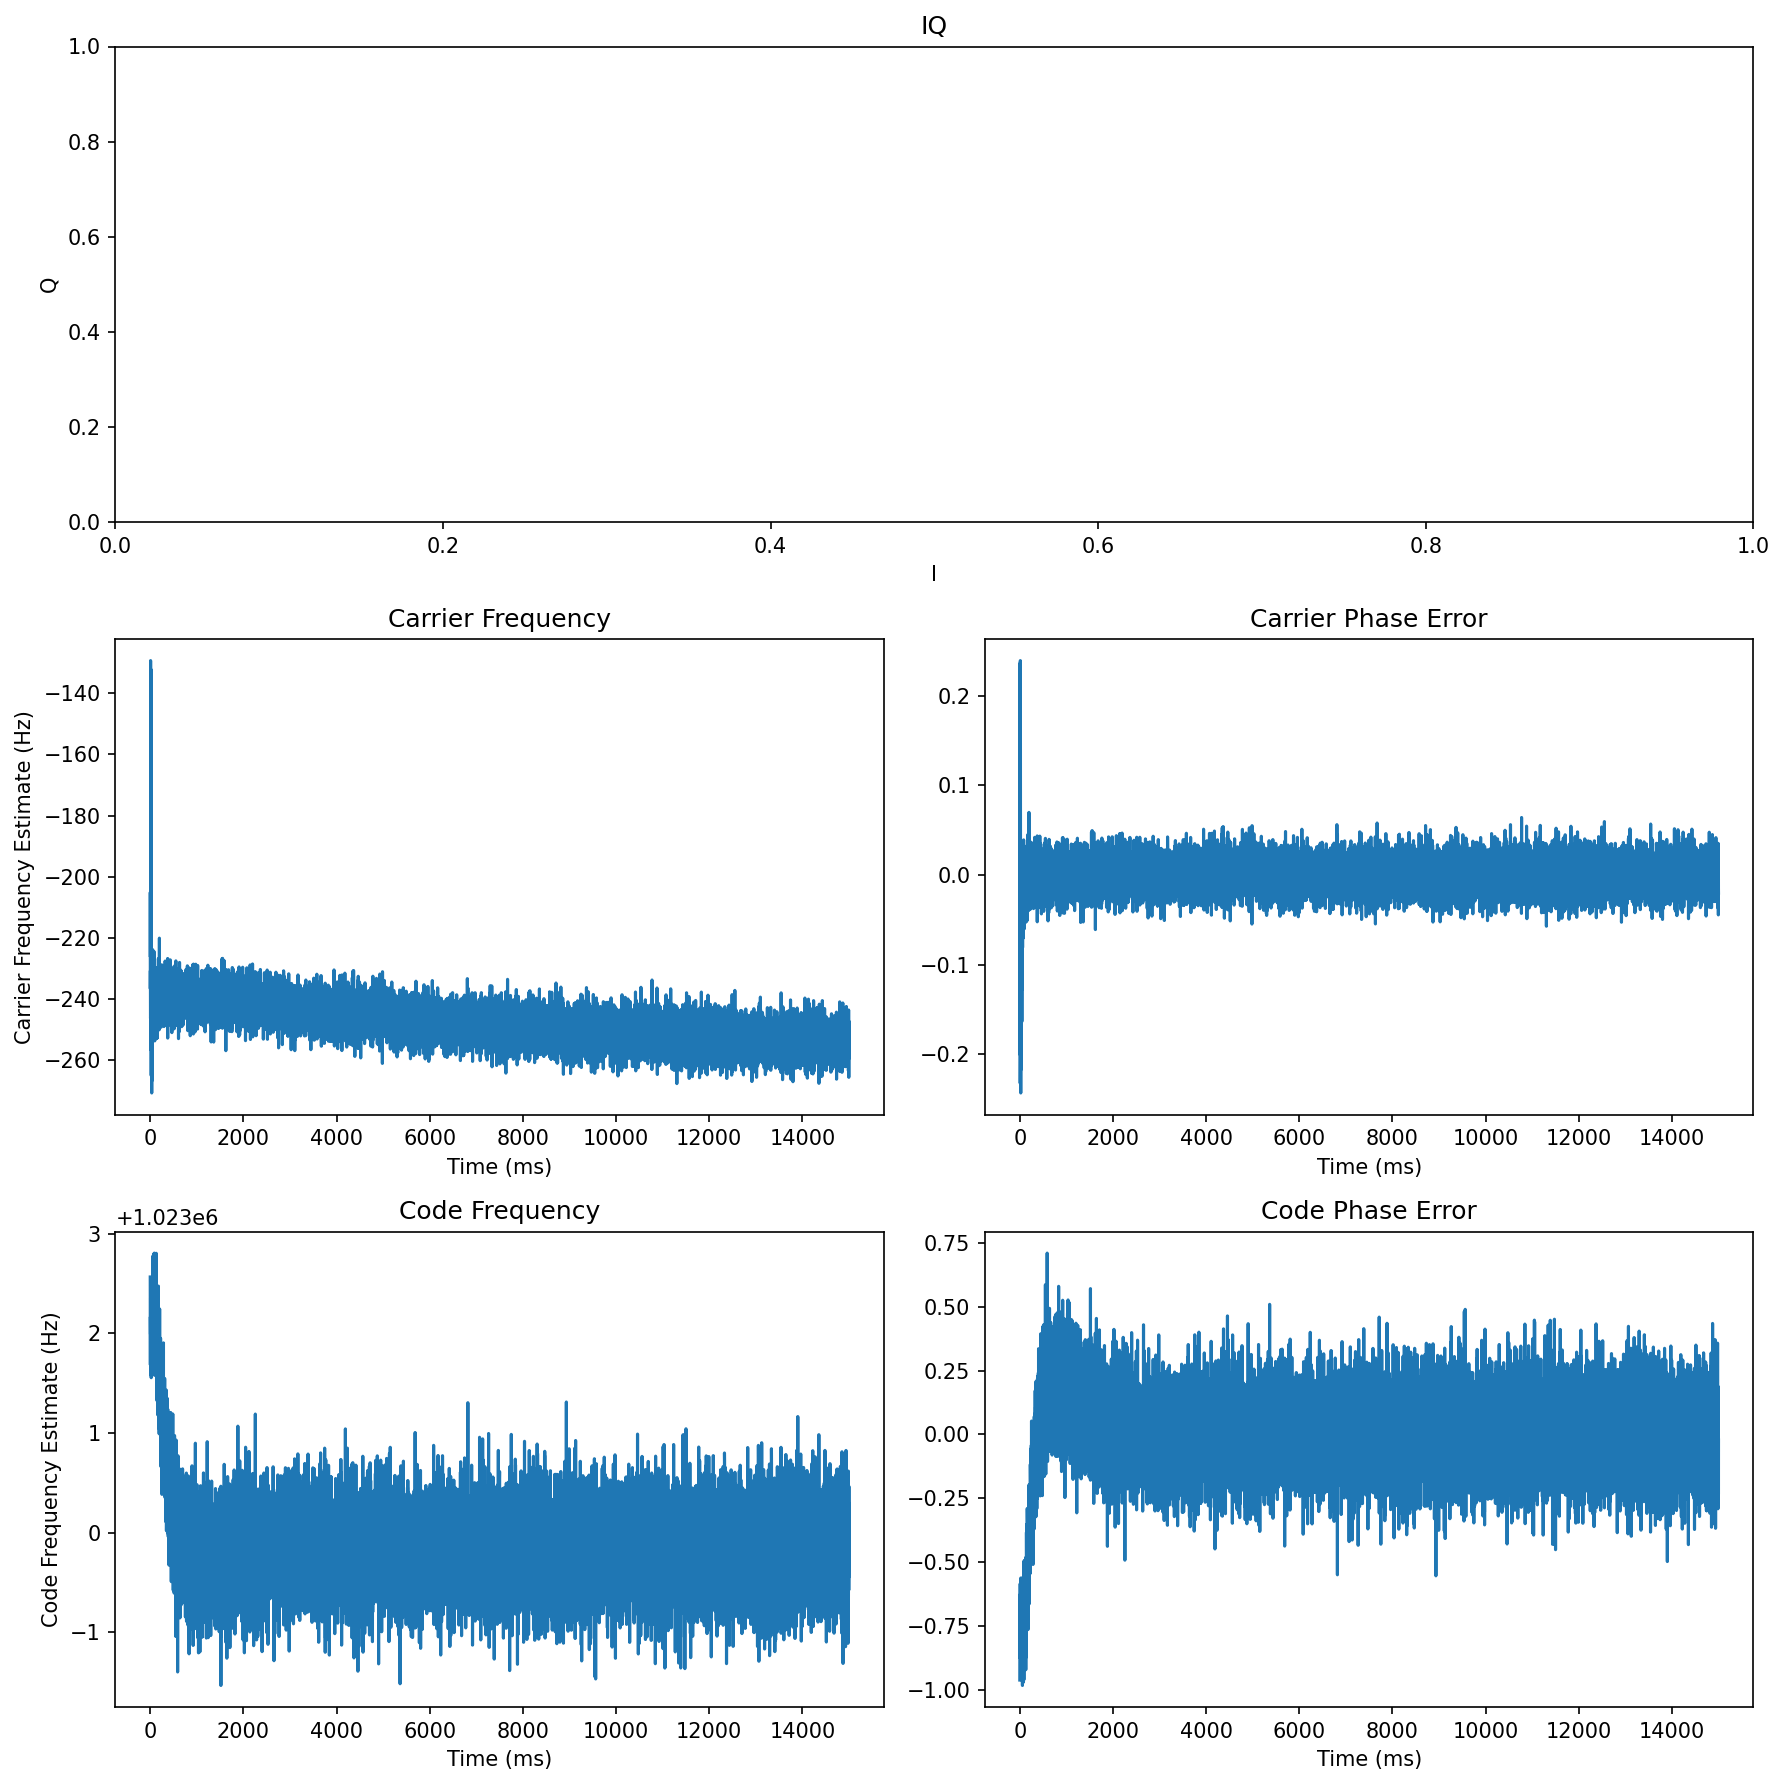

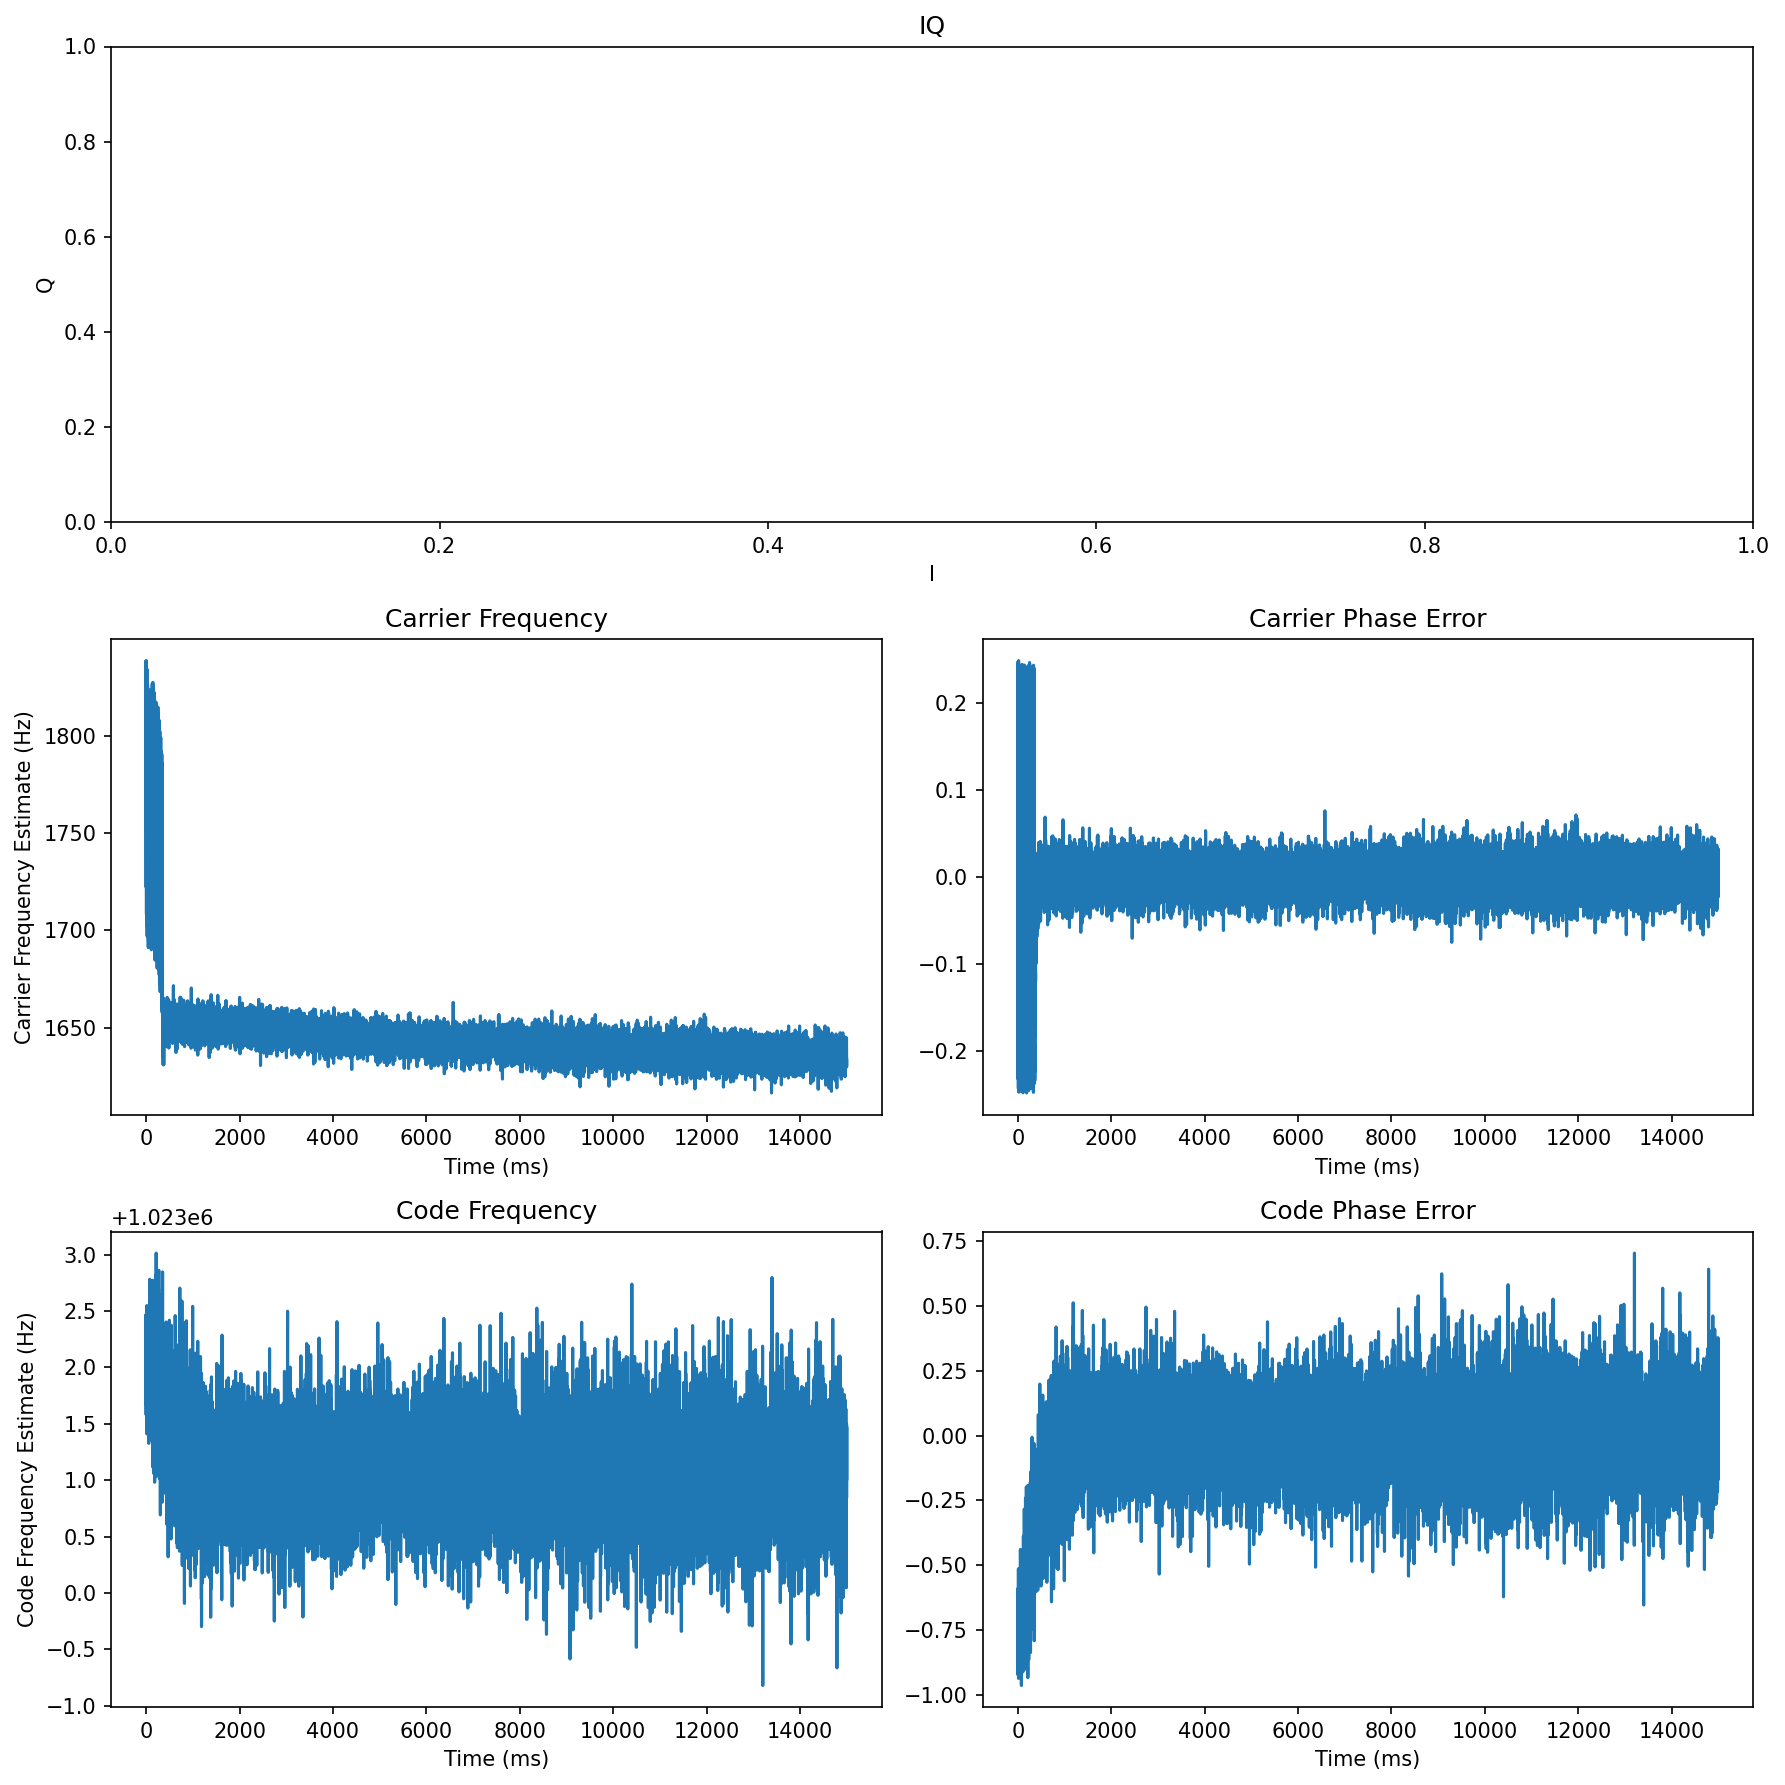

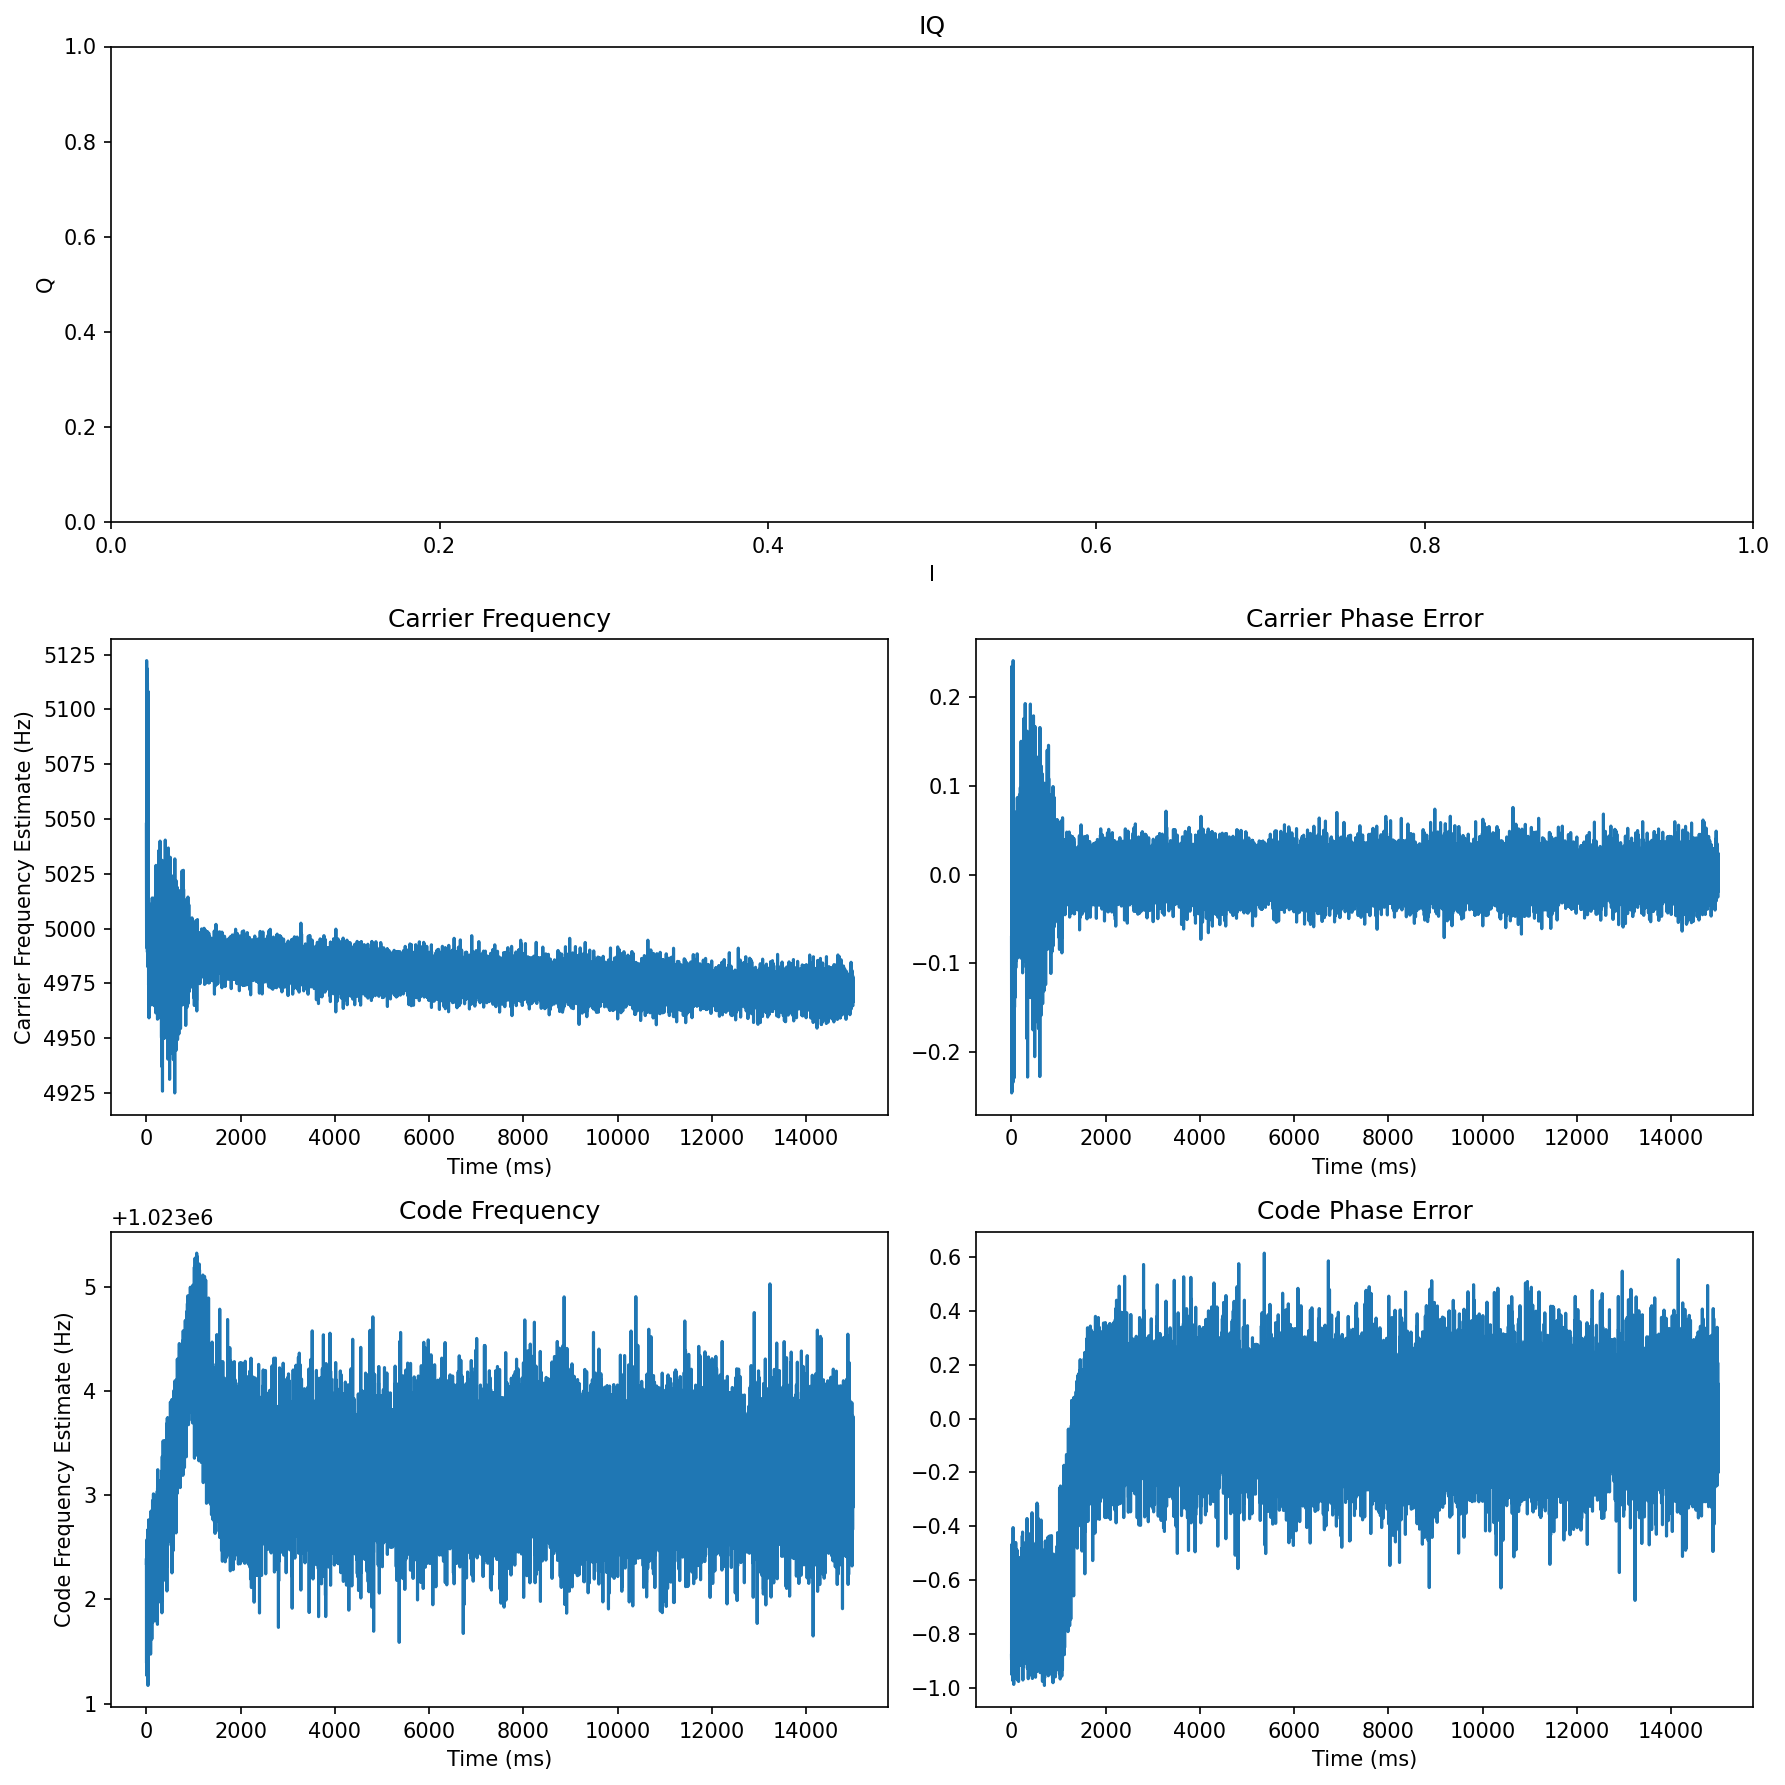

In [10]:
for j in range(np.sum(rx.acquired > 0)):
    # iq = rx.out_samples[j]
    # iq = np.array(iq, dtype=np.complex64)
    # iq = iq / np.max(np.abs(iq))

    debug = rx.channels[j].debug

    # plt.figure()
    # plt.scatter(iq.real, iq.imag, c=np.arange(len(iq)))
    # plt.title(f"SV: {rx.acquired[j]}")

    plt.figure(figsize=(12, 12), dpi=150)

    plt.subplot(3, 2, (1, 2))
    # plt.scatter(iq.real, iq.imag, c=np.arange(len(iq)))
    plt.title("IQ")
    plt.xlabel("I")
    plt.ylabel("Q")

    plt.subplot(3, 2, 3)
    plt.plot(debug.carr_freq)
    plt.title("Carrier Frequency")
    plt.xlabel("Time (ms)")
    plt.ylabel("Carrier Frequency Estimate (Hz)")

    plt.subplot(3, 2, 4)
    plt.plot(debug.carr_err)
    plt.title("Carrier Phase Error")
    plt.xlabel("Time (ms)")

    plt.subplot(3, 2, 5)
    plt.plot(debug.code_freq)
    plt.title("Code Frequency")
    plt.xlabel("Time (ms)")
    plt.ylabel("Code Frequency Estimate (Hz)")

    plt.subplot(3, 2, 6)
    plt.plot(debug.code_err)
    plt.title("Code Phase Error")
    plt.xlabel("Time (ms)")

    plt.tight_layout()